In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/loan_approval_dataset.csv")

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.shape

(4269, 13)

In [5]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
for i in df.columns:
    print(i)

loan_id
 no_of_dependents
 education
 self_employed
 income_annum
 loan_amount
 loan_term
 cibil_score
 residential_assets_value
 commercial_assets_value
 luxury_assets_value
 bank_asset_value
 loan_status


In [8]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [9]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [10]:
print(df["loan_status"].unique())

[' Approved' ' Rejected']


In [11]:
df["loan_status"] = df["loan_status"].astype(str).str.strip()
df["education"] = df["education"].astype(str).str.strip()
df["self_employed"] = df["self_employed"].astype(str).str.strip()

In [12]:
df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

df["education"] = df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

df["self_employed"] = df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

In [13]:
print(df["loan_status"].unique())
print(df["loan_status"].isnull().sum())
print(df.isnull().sum())

[1 0]
0
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [14]:
df = df.drop("loan_id", axis=1)

In [15]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

/Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encou

LogisticRegression(max_iter=1000)

In [18]:
y_pred = lr.predict(X_test)

y_pred[:10]

/Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0])

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.7985948477751756
              precision    recall  f1-score   support

           0       0.80      0.61      0.69       318
           1       0.80      0.91      0.85       536

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854



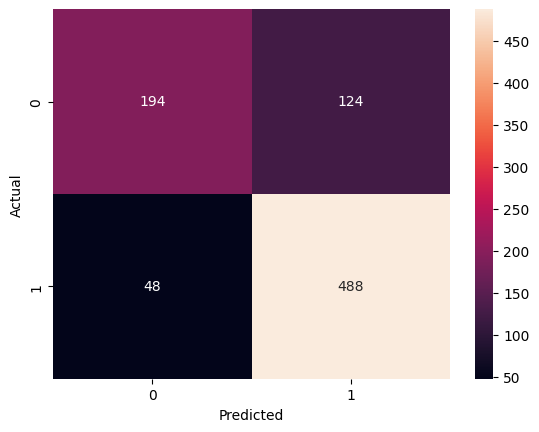

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.977751756440281
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
6,cibil_score,0.814626
5,loan_term,0.064157
4,loan_amount,0.027979
7,residential_assets_value,0.017306
3,income_annum,0.017293
9,luxury_assets_value,0.016934
10,bank_asset_value,0.014995
8,commercial_assets_value,0.014097
0,no_of_dependents,0.007949
2,self_employed,0.002484


In [23]:
import joblib

joblib.dump(rf, "loan_approval_model.pkl")

['loan_approval_model.pkl']

In [24]:
import streamlit as st
import joblib
import pandas as pd

model = joblib.load("loan_approval_model.pkl")

st.title("Loan Approval Prediction System")

2026-06-10 17:59:17.481 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 17:59:17.598 
  command:

    streamlit run /Users/hemalathachodisetti/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-06-10 17:59:17.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 17:59:17.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [25]:
no_of_dependents = st.number_input("Number of Dependents", min_value=0)

education = st.selectbox(
    "Education",
    ["Graduate", "Not Graduate"]
)

self_employed = st.selectbox(
    "Self Employed",
    ["Yes", "No"]
)

income_annum = st.number_input(
    "Annual Income",
    min_value=0
)

loan_amount = st.number_input(
    "Loan Amount",
    min_value=0
)

loan_term = st.number_input(
    "Loan Term",
    min_value=0
)

cibil_score = st.number_input(
    "CIBIL Score",
    min_value=300,
    max_value=900
)

residential_assets_value = st.number_input(
    "Residential Assets Value",
    min_value=0
)

commercial_assets_value = st.number_input(
    "Commercial Assets Value",
    min_value=0
)

luxury_assets_value = st.number_input(
    "Luxury Assets Value",
    min_value=0
)

bank_asset_value = st.number_input(
    "Bank Asset Value",
    min_value=0
)

2026-06-10 18:01:24.944 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:01:24.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:01:24.947 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:01:24.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:01:24.949 Session state does not function when running a script without `streamlit run`
2026-06-10 18:01:24.949 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:01:24.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:01:24.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 18:01

In [26]:
education = 1 if education == "Graduate" else 0

self_employed = 1 if self_employed == "Yes" else 0